# Additional Landmark related Metric Evaluation

In [5]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")
from src.metrics.handcrafted_metrics import compute_extended_hand_metrics, analyze_metrics_vs_grs, compute_rotational_metrics, compute_bimanual_dexterity

In [34]:
df_metrics, correlations = analyze_metrics_vs_grs(
    processed_dir="data/processed/landmark_dataframes/",
    ratings_csv="data/scores/merged_scores.csv",
    metric_func=compute_rotational_metrics,
    fps=30,
    correlation="spearman",
    end = "10fps_processed.pkl"
)

  0%|          | 0/86 [00:00<?, ?it/s]

100%|██████████| 86/86 [00:34<00:00,  2.47it/s]


In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_correlations(correlations_dict, title="Correlation with GRS_Total"):
    """
    Plot correlations as a bar chart with correlation values on top.
    
    Parameters
    ----------
    correlations_dict : dict
        Dictionary of correlations, format: {metric_name: {'correlation': r, 'p_value': p}}
    title : str
        Plot title
    """
    metrics = list(correlations_dict.keys())
    corrs = [v['correlation'] for v in correlations_dict.values()]
    pvals = [v['p_value'] for v in correlations_dict.values()]

    plt.figure(figsize=(10, 6))
    plt.bar(metrics, corrs, color='skyblue')
    plt.ylabel("Pearson Correlation with GRS_Total")
    plt.title(title)
    
    # Show correlation and p-value on top of bars
    for i, (r, p) in enumerate(zip(corrs, pvals)):
        plt.text(i, r, f"{r:.2f}\n(p={p:.2g})", ha='center', va='bottom' if r>=0 else 'top', fontsize=8)
    
    plt.xticks(rotation=90)
    plt.grid(axis='y')
    plt.ylim(-0.8, 0.8)
    plt.show()

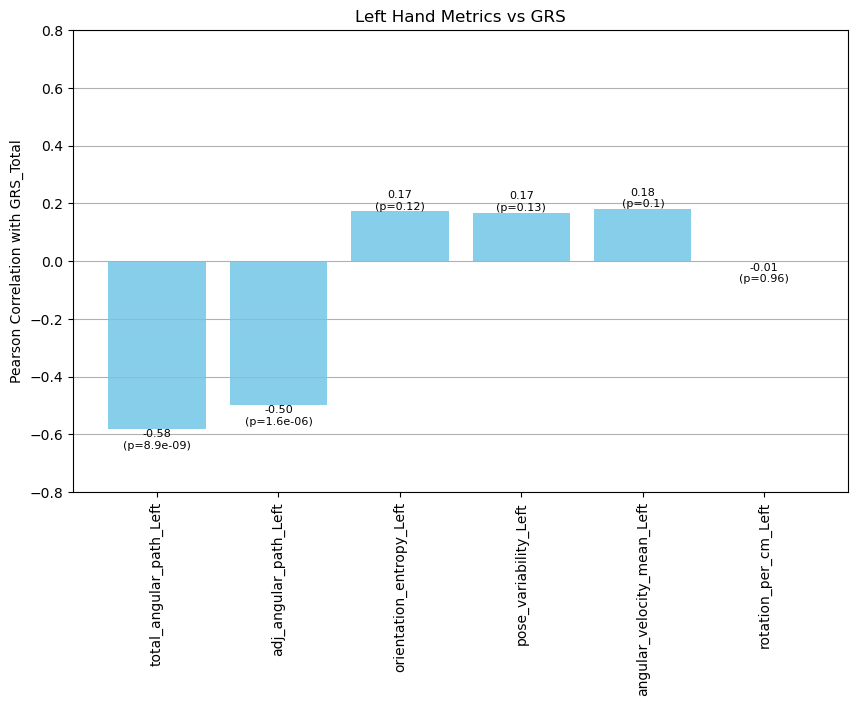

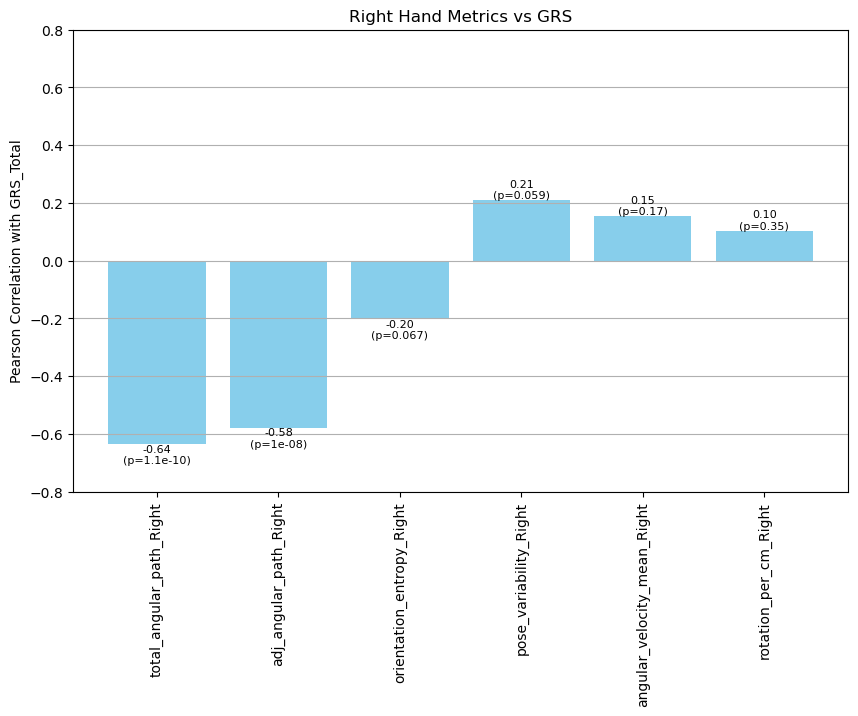

In [18]:
# Left-hand plot
left_metrics = [c for c in df_metrics.columns if c.endswith("_Left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_metrics.columns if c.endswith("_Right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

In [13]:
df_translational_metrics, correlations = analyze_metrics_vs_grs(
    processed_dir="data/processed/",
    ratings_csv="data/scores/merged_scores.csv",
    metric_func=compute_extended_hand_metrics,
    fps=30,
    correlation="spearman",
    end = "10fps_processed.pkl"
)

100%|██████████| 86/86 [00:36<00:00,  2.38it/s]


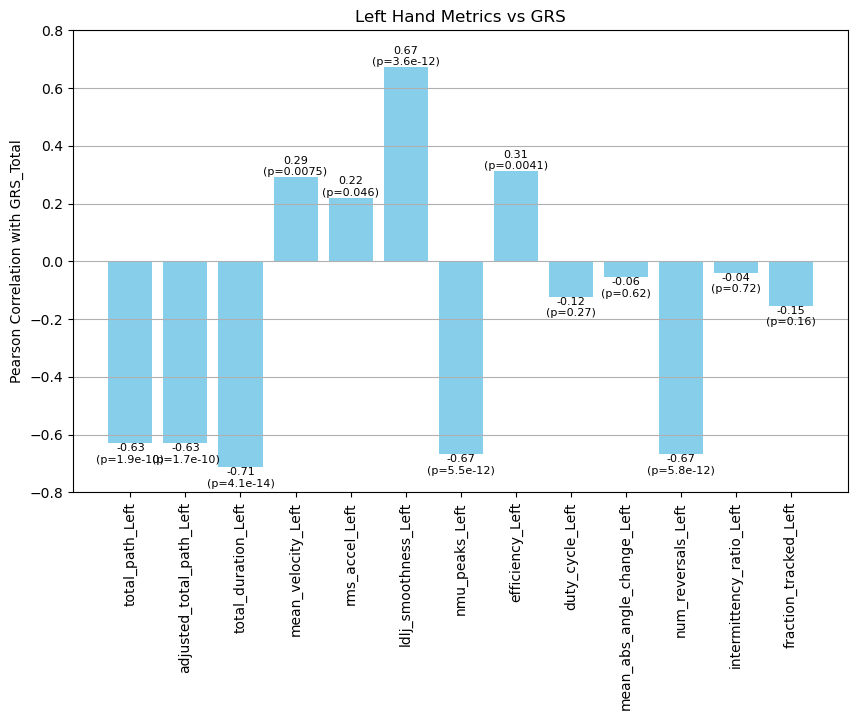

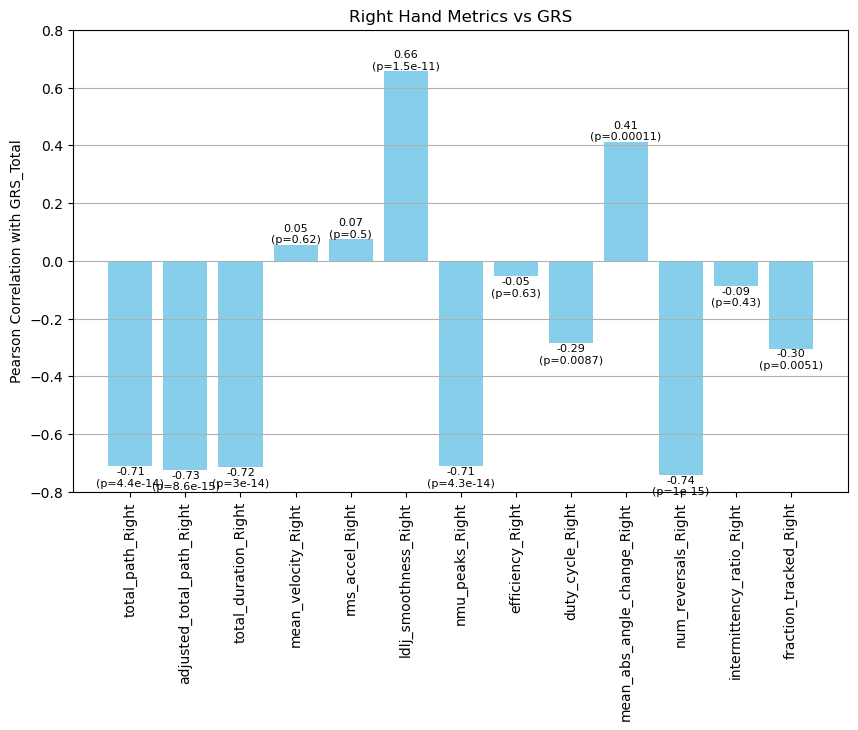

In [5]:
# Left-hand plot
left_metrics = [c for c in df_translational_metrics.columns if c.endswith("_Left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_translational_metrics.columns if c.endswith("_Right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

In [67]:
df_bimanual_metrics, correlations_bimanual = analyze_metrics_vs_grs(
    processed_dir="data/processed/",
    ratings_csv="data/scores/merged_scores.csv",
    metric_func=compute_bimanual_dexterity,
    fps=30,
    correlation="spearman",
    score_col='QRS_Overal',
    end = "10fps_processed.pkl"
)

  0%|          | 0/86 [00:00<?, ?it/s]

100%|██████████| 86/86 [01:17<00:00,  1.11it/s]


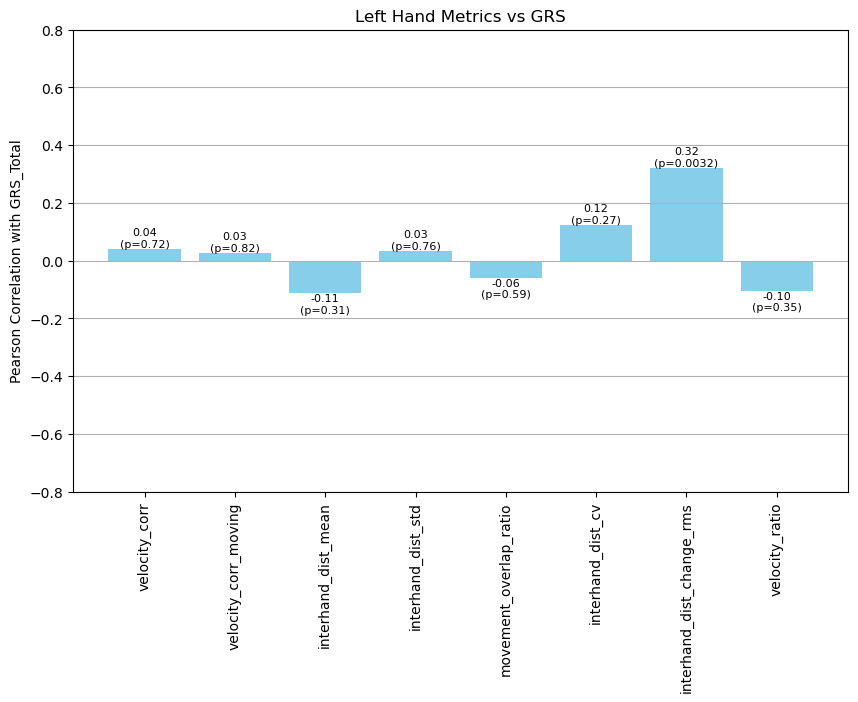

In [69]:
# Left-hand plot
left_metrics = [c for c in df_bimanual_metrics.columns if c.endswith("_Left")]
plot_metric_correlations(correlations_bimanual, title="Left Hand Metrics vs GRS")


In [12]:
# correlation between total_path and total angular path:
from scipy import stats

r, p = stats.spearmanr(df_translational_metrics['total_duration_Right'], df_translational_metrics['ldlj_smoothness_Right'])
print(r, p)

-0.9125981277024473 3.3295395455322166e-33


In [196]:
# merge metric dataframes but only columns that end in '_Left' or '_Right' or Overal
df_metrics = df_metrics[[c for c in df_metrics.columns if c.endswith("_Left") or c.endswith("_Right") or c in ['Participant Number', 'GRS_Total', 'QRS_Overal', 'Case_Number']]]
# same for df_translational_metrics
df_translational_metrics = df_translational_metrics[[c for c in df_translational_metrics.columns if c.endswith("_Left") or c.endswith("_Right")]]
# same for df_bimanual_metrics
df_bimanual_metrics = df_bimanual_metrics[['velocity_corr',
       'velocity_corr_moving', 'interhand_dist_mean', 'interhand_dist_std',
       'movement_overlap_ratio', 'interhand_dist_cv',
       'interhand_dist_change_rms', 'velocity_ratio']]

df_all_metrics = pd.merge(df_metrics, df_translational_metrics, left_index=True, right_index=True)
df_all_metrics = pd.merge(df_all_metrics, df_bimanual_metrics, left_index=True, right_index=True)

In [204]:
# store df with columns: ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
df_all_metrics[['Participant Number', 'GRS_Total', 'QRS_Overal', 'Case_Number', 'adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr', 'interhand_dist_change_rms', 'interhand_dist_mean']].to_csv("data/metrics/best_global_metrics2.csv", index=False)

In [155]:
bow_df = pd.read_csv("data/metrics/top_BoW_video_features.csv")
bow_df = bow_df.sort_values(by='VideoName').reset_index(drop=True)
bow_df = bow_df.drop([c for c in bow_df.columns if not c.startswith('BoW_')], axis=1)
df_all_metrics = pd.merge(df_all_metrics, bow_df, left_index=True, right_index=True)

In [203]:
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

def residual_analysis(df, base_feature, candidate_features, target='QRS_Overal'):
    """
    Analyzes if candidate features explain the variance that the base_feature misses.
    """
    df_clean = df.copy().dropna(subset=[base_feature, target] + candidate_features)
    
    # 1. Train Base Model (Translational only)
    # We use LOSO (Leave-One-Subject-Out) to get 'fair' residuals
    participants = df_clean['Participant Number'].unique()
    df_clean['base_residuals'] = 0.0
    
    for p in participants:
        train = df_clean[df_clean['Participant Number'] != p]
        test = df_clean[df_clean['Participant Number'] == p]
        
        # Simple Linear Regression (or Ridge) for the base model
        X_train = train[[base_feature]]
        y_train = train[target]
        
        model = Ridge(alpha=0.5)
        model.fit(X_train, y_train)
        
        # Calculate Residuals: (Actual - Predicted)
        # Positive residual means the surgeon performed better than their path length suggests
        # Negative residual means they were worse than their path length suggests
        preds = model.predict(test[[base_feature]])
        df_clean.loc[test.index, 'base_residuals'] = test[target].values - preds

    # 2. Correlate New Features with the Residuals
    print(f"--- Correlation with Residuals (Base: {base_feature}) ---")
    results = []
    for feat in candidate_features:
        r, p = pearsonr(df_clean[feat], df_clean['base_residuals'])
        results.append({'Feature': feat, 'Resid_Corr': r, 'p-value': p})
    
    res_df = pd.DataFrame(results).sort_values('Resid_Corr', ascending=False)
    print(res_df)

    top_feats = res_df.sort_values('Resid_Corr', key=lambda x: x.abs(), ascending=False).head(4)['Feature'].tolist()
    
    # 3. Visualization
    plt.figure(figsize=(10, 8))
    for i, feat in enumerate(top_feats): # Plot top 2
        plt.subplot(2, 2, i+1)
        plt.scatter(df_clean[feat], df_clean['base_residuals'], alpha=0.6)
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f"{feat} vs Model Residuals")
        plt.xlabel(feat)
        plt.ylabel("Unexplained Skill (Residual)")
    plt.tight_layout()
    plt.show()
    
    return res_df

# Example Usage:
new_candidates = [col for col in df_all_metrics.columns if col.startswith('BoW_')]
analysis_results = residual_analysis(df_all_metrics, 'adjusted_total_path_Right', new_candidates)

--- Correlation with Residuals (Base: adjusted_total_path_Right) ---


KeyError: 'Resid_Corr'

In [202]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from tqdm import tqdm

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0, 1, 2],
    pca_features=['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = LinearRegression()
        pc_model.fit(df_train[used_pc_cols], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols])
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols + [feat]]
            full_model = LinearRegression()
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Partial_R2'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= 10]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('Mean_Partial_R2', ascending=False)

# Usage:
df_res_leakage_free = leakage_free_residual_analysis(df_all_metrics, new_candidates)
df_res_leakage_free

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]


KeyError: ['BoW_16', 'BoW_2', 'BoW_3', 'BoW_23', 'BoW_25', 'BoW_29', 'BoW_24', 'BoW_17', 'BoW_10', 'BoW_12', 'BoW_28', 'BoW_13']

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 88.74it/s]



          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7677
Overall MAE: 5.0018
Overall Std Dev of Errors: 3.3725

--- Per-Fold Performance Summary ---
           Train_MAE   Test_MAE  Test_Corr
SurgeonID                                 
1           4.433437   7.193657  -0.760071
2           4.584239   3.551516   0.860902
3           4.399945  10.280466   0.742760
4           4.502036   6.248026   0.230870
5           4.491217   5.957055   0.895880
6           4.676753   1.646332   0.908588
7           4.316426   9.287980  -0.715938
9           4.516029   6.120262  -0.991217
10          4.587816   5.336567   0.967016
11          4.676990   1.280106   0.857212
12          4.614545   3.430781  -0.981235
13          4.607782   3.201829   0.995552
14          4.572448   4.513335  -0.138679
15          4.519366   5.639945   0.939480
16          4.330620   9.954764  -0.963486
17          4.642487   2.271312   0.863465
18          4.572007   4.417832   0.877388
19          

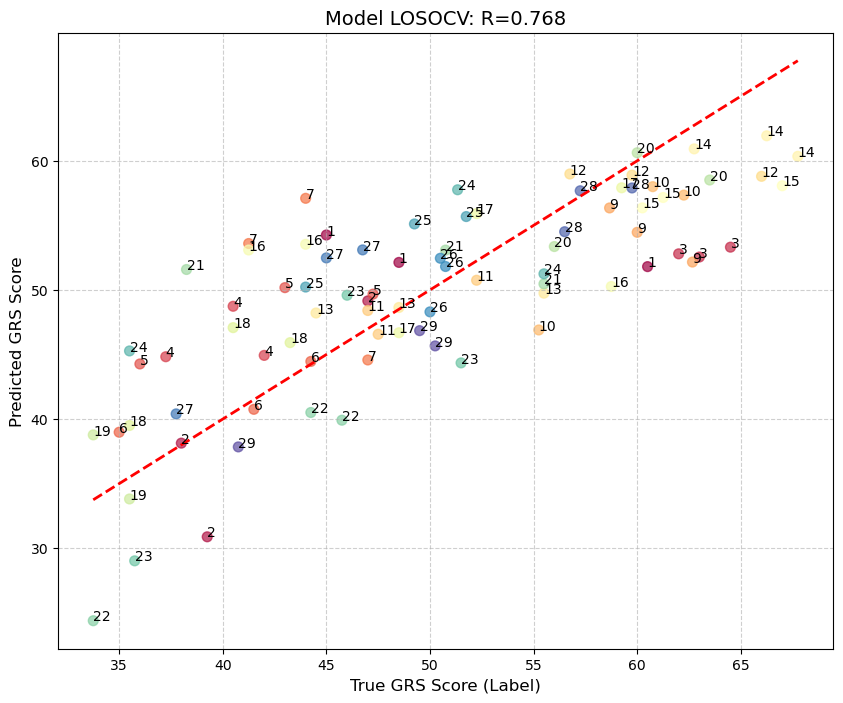

In [195]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and correctly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']]
additional_feature_cols = ['BoW_10', 'BoW_16']  # From handcrafted features analysis
all_feature_cols = feature_cols + additional_feature_cols
X = df_all_metrics[all_feature_cols].values
y = df_all_metrics['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = df_all_metrics['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    
    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0,1,2]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5) 
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()